In [147]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.font_manager as fm

font_path = "../01_wasting_stunting/Microsoft Aptos Fonts/Aptos.ttf"  
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = prop.get_name()

import os

# Compare it to Last Year

In [148]:
annual_immunization_df = pd.read_csv('outputs/annual_immunization.csv')
annual_immunization_df['PSGC'] = annual_immunization_df['PSGC'].astype(str).str.zfill(10)

region_df = annual_immunization_df[annual_immunization_df.Income.isnull()].copy()

In [149]:
region2024_df = region_df[region_df.Year == 2025].copy()
region2024_df['FIC_eligible'] = region2024_df['FIC_Total'] / (region2024_df['FIC_Percent'] / 100)
national_baseline = region2024_df['FIC_Total'].sum() / region2024_df['FIC_eligible'].sum()
print(f'The 2024 national baseline is {(national_baseline * 100):.2f}%.')

The 2024 national baseline is 64.54%.


In [150]:
# load + clean
immunization2025_df = pd.read_csv('outputs/monthly_immunization.csv').dropna()
immunization2025_df.PSGC = immunization2025_df.PSGC.astype(str).str.zfill(10)

# keep municipal / city level (exclude provinces)
LGU2025_df = immunization2025_df[
    immunization2025_df['Level'] != 'Prov'
].copy()

# sort so latest month is last
LGU2025_df = LGU2025_df.sort_values(['PSGC'])

# get latest cumulative record per LGU (municipality/city)
LGU_latest = LGU2025_df.groupby('PSGC').tail(1).copy()

LGU_FIC_total = LGU2025_df.groupby('PSGC')['FIC_Total'].sum()

In [151]:
LGU_latest['FIC_eligible'] = LGU_latest['FIC_Total'] / (
    LGU_latest['FIC_Percent'].replace(0, np.nan) / 100
)

LGU_FIC_Eligible = LGU_latest[['PSGC', 'Area', 'FIC_eligible']].set_index('PSGC')

In [152]:
income_map = {
    # 1st class variants
    '1st': '1st',
    '1st*': '1st',
    '1st (as Mun)': '1st',
    '1st* (reclass 2005)': '1st',

    # 2nd class
    '2nd': '2nd',
    '2nd*': '2nd',

    # 3rd class
    '3rd': '3rd',
    '3rd*': '3rd',

    # 4th class
    '4th': '4th',
    '4th*': '4th',

    # 5th class
    '5th': '5th',
    '5th*': '5th',

    # 6th class
    '6th': '6th',
    '6th*': '6th',

    # Special cases
    'Special': '1st',   # treat as 1st
    '-': np.nan        # or keep as '-' if needed
}
LGU_latest['Income'] = LGU_latest['Income'].map(income_map)

In [153]:
psgc_income_map = dict(zip(LGU_latest.PSGC, LGU_latest.Income))

In [154]:
LGU_fic_df = LGU_FIC_Eligible.join(LGU_FIC_total.rename('FIC_Total'))
LGU_fic_df['FIC_Percent'] = LGU_fic_df.FIC_Total / LGU_fic_df.FIC_eligible

def classify_coverage(x):
    if x >= 0.95:
        return 'Great'
    elif x >= national_baseline:
        return 'Okay'
    else:
        return 'Needs Improvement'


LGU_fic_df['Coverage_Level'] = LGU_fic_df['FIC_Percent'].apply(classify_coverage)
LGU_fic_df.reset_index(inplace=True)
LGU_fic_df.Coverage_Level.value_counts(normalize=True)

Coverage_Level
Needs Improvement    0.631547
Okay                 0.308161
Great                0.060292
Name: proportion, dtype: float64

In [212]:
vac_df = immunization2025_df.iloc[:, 6:]
vac_cols = [vac_index for vac_index in vac_df.columns if vac_index.endswith('Total')][:-2]
vac_result = immunization2025_df.groupby('PSGC')[vac_cols].sum()

fic = LGU_fic_df[['PSGC', 'FIC_eligible']]

vac_result = vac_result.merge(LGU_fic_df, on='PSGC')
for vac_col in vac_cols:
    percent_col = vac_col.replace('_Total', '_Percent')
    
    vac_result[percent_col] = (
        vac_result[vac_col] / vac_result['FIC_eligible']
    ) * 100

<Axes: >

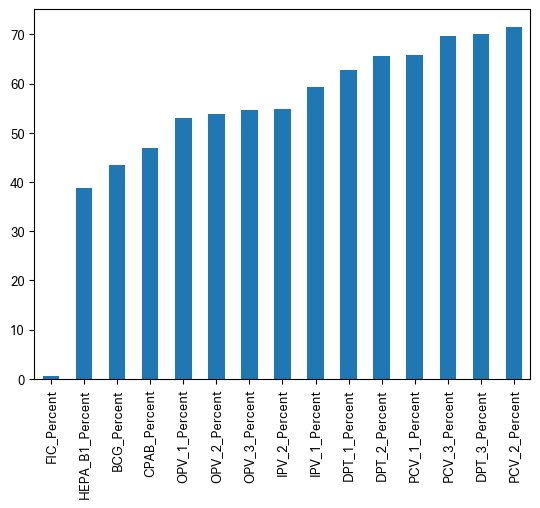

In [221]:
vac_cols = [vac_index for vac_index in vac_result.columns if vac_index.endswith('Percent')]
vac_result[vac_cols].median().sort_values().plot(kind='bar')

In [222]:
vac_result[vac_cols].median()

FIC_Percent         0.596323
BCG_Percent        43.564217
HEPA_B1_Percent    38.812485
CPAB_Percent       47.002955
DPT_1_Percent      62.702493
DPT_2_Percent      65.575129
DPT_3_Percent      70.172650
OPV_1_Percent      53.075804
OPV_2_Percent      53.862108
OPV_3_Percent      54.688402
IPV_1_Percent      59.221658
IPV_2_Percent      54.853339
PCV_1_Percent      65.755811
PCV_2_Percent      71.566996
PCV_3_Percent      69.601174
dtype: float64

# Choropleth

In [157]:
folder_path = '../01_wasting_stunting/faeldon philippines-json-maps master 2023-geojson_provdists/hires'

gdfs = []

# Loop through all json files
for file in os.listdir(folder_path):
    if file.endswith('.json'):
        path = os.path.join(folder_path, file)
        gdf = gpd.read_file(path)
        gdfs.append(gdf)

# Combine into one GeoDataFrame
geo_df = pd.concat(gdfs, ignore_index=True)
geo_df['adm2_psgc'] = geo_df['adm2_psgc'].astype(str).str.zfill(10)

LGU_geo_df = geo_df.merge(
    LGU_fic_df,
    left_on='adm3_en',
    right_on='Area',
    how='left'
)

In [158]:
LGU_geo_df.Coverage_Level = LGU_geo_df.Coverage_Level.fillna('Needs Improvement')

/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_24608/829462112.py:11: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  LGU_geo_df.plot(


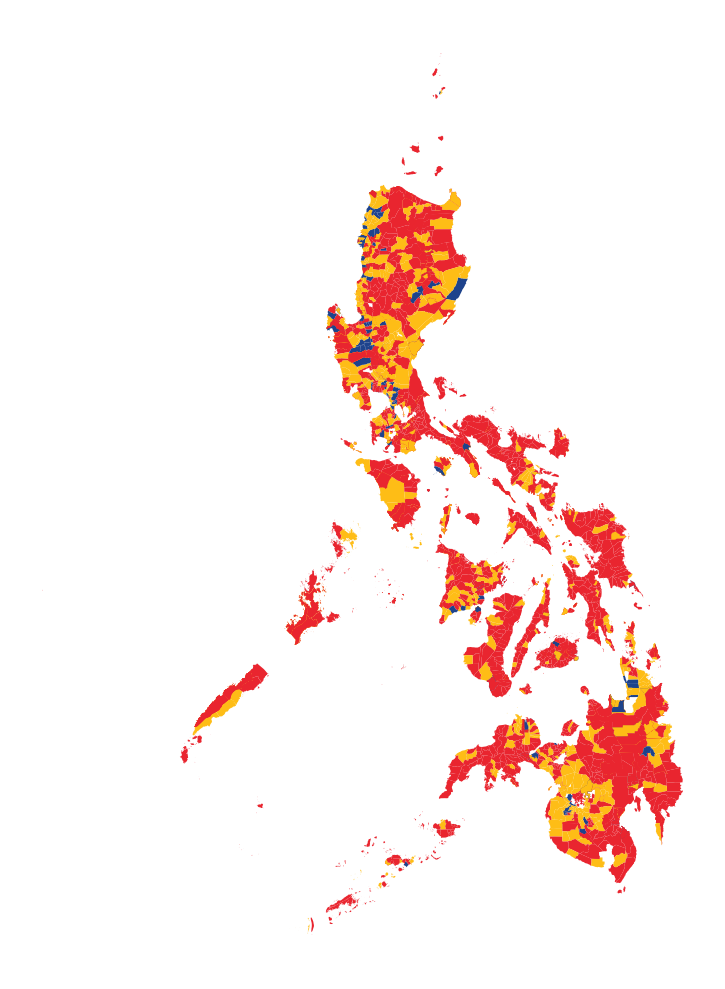

In [159]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Define color mapping by category
color_map = {
    'Needs Improvement': '#e9252f',  # Red
    'Okay': '#febd16',               # Yellow
    'Great': '#1e438c'               # Blue
}

# Plot directly using GeoPandas categorical mapping
LGU_geo_df.plot(
    column='Coverage_Level',
    legend=True,
    #legend_kwds={'title': 'Coverage Level', 'loc': 'lower right'},
    color=LGU_geo_df['Coverage_Level'].map(color_map),
    linewidth=0.1,
    #edgecolor='white',
    ax=ax
)

ax.axis('off')
plt.tight_layout()
plt.show()

# See the Growth Rate

In [160]:
# Get the average annual growth rate in FIC coverage from 2018–2025
df = region_df.sort_values(['PSGC', 'Year'])
df['growth_rate'] = df.groupby('PSGC')['FIC_Percent'].pct_change()
df['growth_factor'] = 1 + df['growth_rate']
gmean_growth = (
    df.groupby('PSGC')['growth_factor']
    .apply(lambda x: np.prod(x) ** (1 / len(x)))
)
gmean_growth_rate = gmean_growth - 1
province_names = df[['PSGC', 'Area']].drop_duplicates().set_index('PSGC')

result = province_names.join(gmean_growth_rate.rename('avg_annual_growth'))

result['Area'] = result['Area'].replace({
    'NEGROS ISLAND REGION (NIR)': 'NIR'
})

# set an order
region_order = [
    'NCR', 'CAR', 'Region 1', 'Region 2', 'Region 3', 'Region 4A',
    'Region 4B', 'Region 5', 'Region 6', 'NIR',
    'Region 7', 'Region 8', 'Region 9', 'Region 10',
    'Region 11', 'Region 12', 'Region 13', 'BARMM'
]

region_order = [region.upper() for region in region_order]

result_ordered = (
    result
    .set_index('Area')
    .loc[region_order]   # this enforces the order
    .reset_index()
)

/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_24608/3097740473.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(result_ordered.Area, rotation=45, ha='right', rotation_mode='anchor')


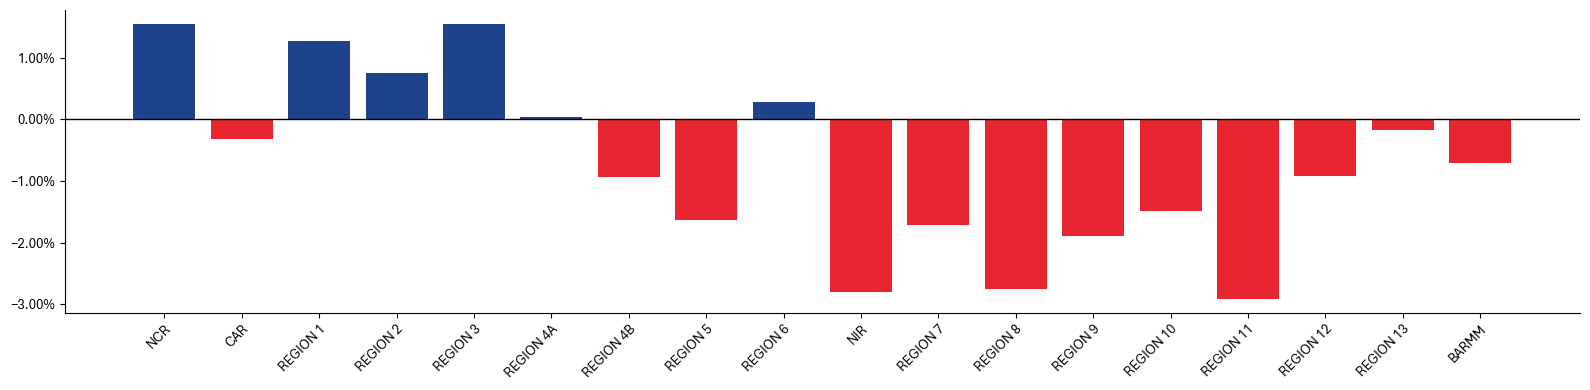

In [161]:
fig, ax = plt.subplots(figsize=(16, 4))

# Assign colors based on sign
colors = np.where(
    result_ordered.avg_annual_growth >= 0,
    '#1e438c',  # blue
    '#e9252f'   # red
)

ax.bar(result_ordered.Area, result_ordered.avg_annual_growth, color=colors)

ax.set_xticklabels(result_ordered.Area, rotation=45, ha='right', rotation_mode='anchor')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))  

ax.axhline(0, color='black', linewidth=1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [162]:
folder_path = '../01_wasting_stunting/faeldon philippines-json-maps master 2023-geojson_regions/hires'

gdfs = []

# Loop through all json files
for file in os.listdir(folder_path):
    if file.endswith('.json'):
        path = os.path.join(folder_path, file)
        gdf = gpd.read_file(path)
        gdfs.append(gdf)

# Combine into one GeoDataFrame
geo_df = pd.concat(gdfs, ignore_index=True)
geo_df.adm2_psgc = geo_df.adm2_psgc.astype(str).str.zfill(10)

prov_geo_df = geo_df.merge(
    gmean_growth_rate,
    left_on='adm2_psgc',
    right_on='PSGC',
    how='left'
)